In [16]:
from ngsxditto import *
from ngsolve import *
from xfem import *
import ngsolve.webgui as ngw
from netgen.occ import *

In [17]:
domain = MoveTo(-1, -1).Rectangle(2, 2).Face()
domain.edges.Max(X).name = "right"
domain.edges.Min(X).name = "left"
domain.edges.Min(Y).name = "bottom"
domain.edges.Max(Y).name = "top"
mesh = Mesh(OCCGeometry(domain, dim=2).GenerateMesh(maxh=0.15))

In [18]:
dt = 0.05
t = Parameter(0)
starting_levelset = (5*x**2 + y**2)**(1/2) - 2.0/3.0
transport = ExplicitDGTransport(mesh, dt=dt, order=2, compile=False)
levelset = LevelSetGeometry(transport)
levelset.Initialize(starting_levelset)

In [19]:
fluid1_params = FluidParameters(viscosity=5e-2, surface_tension_coeff=1)
fluid2_params = FluidParameters(viscosity=5e-2)

mean_curvature = MeanCurvatureSolver(mesh, order=2, lset=levelset)
mean_curvature.Step()
fluid = TwoPhaseTaylorHood(mesh, fluid1_params=fluid1_params, fluid2_params=fluid2_params, lset=levelset, surface_tension=mean_curvature.H, dt=dt, order=3,
                           ghost_stab=1, nitsche_stab=200)
fluid.Initialize(dirichlet={".*": CF((0, 0))})
fluid.ValidateStep()
sol = fluid.SolveStokes()
gfu, gfp, gfn = sol.components
u_neg, u_pos = gfu.components
p_neg, p_pos = gfp.components
ngw.Draw(IfPos(levelset.lsetp1, u_pos, u_neg), mesh, "u")
ngw.Draw(IfPos(levelset.lsetp1, p_pos, p_neg), mesh, "u")

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

BaseWebGuiScene

Solver:  |████████████████████████████████████████✗︎ ▃▅▇ 100% in 50s (~1s, 0.0%/s

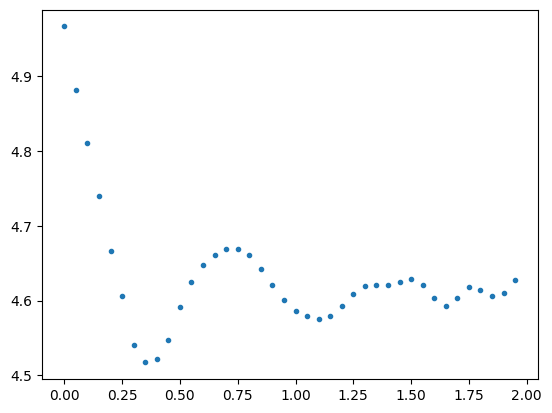

Solver:  |████████████████████████████████████████✗︎ ▄▆█ 100% in 50s (~0s, 0.0%/s

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

on 100.0%: moving stokes: 0.21060419082641602                                   
on 100.0%: vel ext.: 3.788130760192871                                          
on 100.0%: levelset: 45.06436038017273                                          
on 100.0%: mean curvature: 0.48277854919433594                                  
on 100.0%: sphericity: 0.12747955322265625                                      
on 100.0%: animation: 0.14205121994018555                                       
Solver:  |████████████████████████████████████████✗︎ 100% in 49.9s (0.02%/s)     


In [20]:
velocity_extension = DiffusionBasedVelocityExtension(levelset)

velocity_extension.SetRhs(fluid.gfu.components[0])
levelset.transport.SetWind(velocity_extension.field)

end_time = 2

time_loop = TimeLoop(time=t, dt=dt, end_time=end_time)

sphericity = SphericityDiagram(levelset, time=t, name="sphericity")

cf_neg = Norm(fluid.gfu.components[0])
cf_pos = Norm(fluid.gfu.components[1])
animation = UnfittedNGSWebguiPlot(levelset, cf_neg=cf_neg, cf_pos=cf_pos,
                                  order=fluid.order, time=t, end_time=end_time,
                                  name="animation", min=0, max=0.5, autoscale=False)

time_loop.Register(fluid, name="moving stokes")
time_loop.Register(velocity_extension, name="vel ext.")
time_loop.Register(levelset, name="levelset")
time_loop.Register(mean_curvature, name="mean curvature")

time_loop.Register(sphericity, name="sphericity")
time_loop.Register(animation, name="animation")
time_loop()
